# Attention Is All You Need — 실습 코드 1
## Scaled Dot-Product Attention 완전 해부

**논문:** Vaswani et al., 2017 — "Attention Is All You Need"

---

### 이 노트북에서 배우는 것

| 블록 | 핵심 질문 |
|------|-----------|
| B | "유사도"를 어떻게 숫자로 계산하나요? |
| C–D | Q / K / V 란 무엇이고, shape은 어떻게 변하나요? |
| E | 왜 √d_k로 나눠야 하나요? |
| F | 미래 토큰을 어떻게 가리나요? |
| G–H | Multi-Head Attention은 Single-Head와 무엇이 다른가요? |
| 부록 | Label Smoothing, LR 스케줄은 어떻게 작동하나요? |

### 읽는 방법
- **회색 코드 셀:** Shift+Enter로 실행합니다.
- **`[실험]` 주석:** 해당 줄의 숫자를 바꾸고 다시 실행해 보세요.
- 마크다운 셀을 먼저 읽어 **개념**을 이해한 뒤 코드를 실행합니다.

## 셀 1 — 라이브러리 & 헬퍼 함수 설정

In [1]:
# ============================================================
# 라이브러리 임포트
# ============================================================
import math          # sqrt 등 수학 함수
import unicodedata   # 한글 글자 폭 계산 (출력 정렬용)
import warnings

import torch               # 딥러닝 텐서 연산
import torch.nn as nn      # 신경망 레이어 (Linear, Dropout 등)
import torch.nn.functional as F  # softmax, log_softmax 등

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ── 한글 폰트 등록 (그래프 글자 깨짐 방지) ────────────────────
def _setup_korean_font() -> str:
    """
    시스템에서 한글 폰트를 찾아 matplotlib 에 등록합니다.
    - 맥: AppleSDGothicNeo
    - 윈도우: Malgun Gothic (맑은 고딕)
    - 리눅스(Ubuntu/Colab): NanumGothic, Noto Sans CJK
    """
    name_candidates = [
        "NanumGothic", "Malgun Gothic", "AppleGothic",
        "Noto Sans CJK KR", "Noto Sans KR", "Noto Sans CJK JP"
    ]
    installed = {f.name for f in fm.fontManager.ttflist}
    for name in name_candidates:
        if name in installed:
            return name

    path_candidates = [
        '/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
        '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc',
        '/System/Library/Fonts/AppleSDGothicNeo.ttc',
        'C:/Windows/Fonts/malgun.ttf',
    ]
    for path in path_candidates:
        try:
            fm.fontManager.addfont(path)
            return fm.FontProperties(fname=path).get_name()
        except Exception:
            continue
    warnings.warn("한글 폰트를 찾지 못했습니다. 그래프 글자가 깨져 보일 수 있습니다.")
    return "DejaVu Sans"

_korean_font = _setup_korean_font()
plt.rcParams['font.family']        = _korean_font
plt.rcParams['axes.unicode_minus'] = False    # 마이너스 기호 깨짐 방지
print(f"한글 폰트: '{_korean_font}'")

# ── 재현성을 위한 난수 고정 ────────────────────────────────────
torch.manual_seed(42)
torch.set_printoptions(precision=3, sci_mode=False)

# ── 행렬 콘솔 출력 헬퍼 ─────────────────────────────────────────
def _vw(s: str) -> int:
    """
    문자열의 화면 표시 너비를 반환합니다.
    한글/한자처럼 넓은 글자(Wide)는 터미널에서 2칸을 차지하고,
    영문/숫자는 1칸을 차지합니다.
    """
    return sum(2 if unicodedata.east_asian_width(c) in ("W", "F") else 1 for c in s)

def _pad(s: str, w: int) -> str:
    """화면 표시 너비 기준으로 오른쪽 정렬 공백을 추가합니다."""
    return " " * max(0, w - _vw(s)) + s

def show_matrix(mat, row_labels, col_labels, title="", cellw=8):
    """
    작은 2D 텐서를 토큰 레이블과 함께 보기 좋게 출력합니다.

    Parameters
    ----------
    mat        : 2D 텐서 또는 numpy 배열 (shape: seq x seq)
    row_labels : 행에 붙일 레이블 리스트 (예: 토큰 목록)
    col_labels : 열에 붙일 레이블 리스트
    title      : 표 위에 출력할 제목 (빈 문자열이면 생략)
    cellw      : 숫자 셀 하나의 화면 너비
    """
    if hasattr(mat, "detach"):
        mat = mat.detach().numpy()
    if title:
        print(f"[{title}]")
    lw = max(_vw(r) for r in row_labels) + 1
    print(" " * lw + "".join(_pad(c, cellw) for c in col_labels))
    for rl, row in zip(row_labels, mat):
        cells_str = "".join(
            _pad("-inf" if v == float('-inf') else f"{v:.2f}", cellw)
            for v in row
        )
        print(_pad(rl, lw) + cells_str)
    print()

print("헬퍼 함수 정의 완료")

한글 폰트: 'Noto Sans CJK JP'
헬퍼 함수 정의 완료


## 블록 B — "유사도"를 숫자로: 내적(Dot Product) 직관

Attention의 핵심 아이디어는 **"지금 이 단어가 다른 단어를 얼마나 참고해야 하는가?"**를
숫자로 계산하는 것입니다.

그 방법이 **내적(dot product)**입니다:

$$\text{유사도}(a, b) = a \cdot b = \sum_{i} a_i \cdot b_i$$

- 두 벡터가 **같은 방향**: 내적이 **크게** 나옵니다.
- **수직(무관계)**: 내적이 **0** 에 가깝습니다.
- **반대 방향**: **음수**가 됩니다.

이 점수들을 **softmax**에 통과시키면 합이 1인 확률 분포가 되고,
이 확률이 바로 "얼마나 참고할 것인가"의 **attention weight**입니다.

Query: '고양이'  (벡터 = [1.0, 0.2])
----------------------------------------------------
  단어          내적 점수   벡터
----------------------------------------------------
  고양이         1.040   [1.0, 0.2]
  강아지         0.960   [0.9, 0.3]
  자동차         0.000   [-0.2, 1.0]

softmax 확률 (= attention weight):
  고양이    0.439  █████████████
  강아지    0.405  ████████████
  자동차    0.155  ████

=> '고양이'는 방향이 비슷한 '강아지'(0.405)와 자기 자신(0.439)에 주목합니다.
   '자동차'는 방향이 수직이라 낮은 가중치(0.155)를 받습니다.


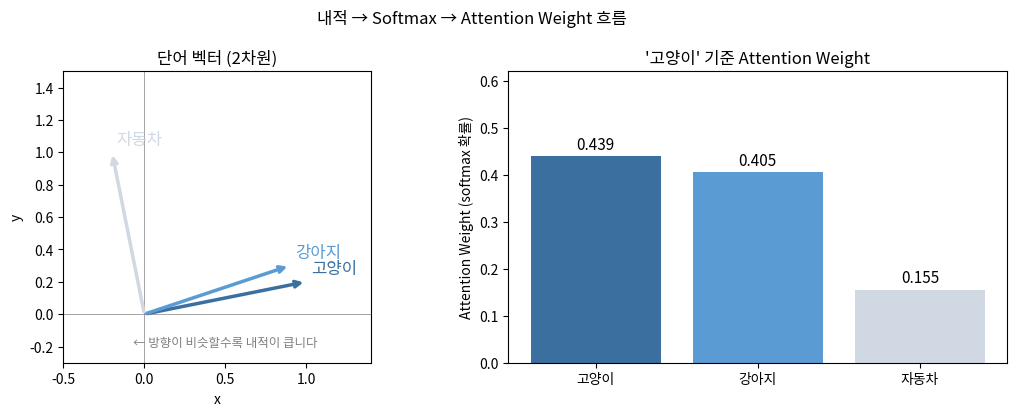

In [2]:
# ============================================================
# 블록 B — 내적 = 유사도 직관 데모 (2차원 장난감 벡터)
# ============================================================

# 단어마다 2차원 벡터를 임의로 정합니다.
# 실제 모델에서는 학습을 통해 이 벡터가 결정됩니다.
word_vectors = {
    "고양이": [1.0,  0.2],   # x축 방향에 가까운 벡터
    "강아지": [0.9,  0.3],   # 고양이와 비슷한 방향
    "자동차": [-0.2, 1.0],   # 고양이와 거의 수직 (방향이 달라 무관)
}

def dot_product(a, b):
    """파이썬 기본 리스트로 내적을 직접 계산합니다."""
    return sum(ai * bi for ai, bi in zip(a, b))

# "고양이"가 Query(질문)입니다: "나는 어떤 단어와 관련 있을까?"
query_word = "고양이"
query_vec  = word_vectors[query_word]

print(f"Query: '{query_word}'  (벡터 = {query_vec})")
print("-" * 52)
print(f"  {'단어':<6} {'내적 점수':>10}   벡터")
print("-" * 52)

raw_scores = {}
for word, vec in word_vectors.items():
    score = dot_product(query_vec, vec)
    raw_scores[word] = score
    print(f"  {word:<6} {score:>10.3f}   {vec}")

# ── softmax: 점수 → 확률 ─────────────────────────────────────
# exp(score) 를 전체 합으로 나눠 합이 1인 확률 분포를 만듭니다.
exp_scores = {w: math.exp(s) for w, s in raw_scores.items()}
total      = sum(exp_scores.values())
probs      = {w: exp_scores[w] / total for w in word_vectors}

print()
print("softmax 확률 (= attention weight):")
for word, prob in probs.items():
    bar = "█" * int(prob * 30)
    print(f"  {word:<6} {prob:.3f}  {bar}")

print()
print("=> '고양이'는 방향이 비슷한 '강아지'(0.405)와 자기 자신(0.439)에 주목합니다.")
print("   '자동차'는 방향이 수직이라 낮은 가중치(0.155)를 받습니다.")

# ── 시각화 ──────────────────────────────────────────────────
words_list = list(probs.keys())
prob_list  = list(probs.values())
colors     = ["#3b6fa0", "#5a9bd4", "#cfd8e3"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# 왼쪽: 2D 벡터 공간에서 화살표로 표현
ax = axes[0]
for i, (word, vec) in enumerate(word_vectors.items()):
    ax.annotate("", xy=vec, xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color=colors[i], lw=2.5))
    ax.text(vec[0] + 0.03, vec[1] + 0.05, word, fontsize=12, color=colors[i])
ax.set_xlim(-0.5, 1.4); ax.set_ylim(-0.3, 1.5)
ax.axhline(0, color="gray", lw=0.5); ax.axvline(0, color="gray", lw=0.5)
ax.set_title("단어 벡터 (2차원)"); ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_aspect("equal")
ax.text(0.5, -0.2, "← 방향이 비슷할수록 내적이 큽니다", ha="center", fontsize=9, color="gray")

# 오른쪽: attention weight 막대그래프
ax = axes[1]
bars = ax.bar(words_list, prob_list, color=colors)
ax.set_ylim(0, 0.62); ax.set_ylabel("Attention Weight (softmax 확률)")
ax.set_title(f"'{query_word}' 기준 Attention Weight")
for b, p in zip(bars, prob_list):
    ax.text(b.get_x() + b.get_width() / 2, p + 0.015, f"{p:.3f}", ha="center", fontsize=11)

fig.suptitle("내적 → Softmax → Attention Weight 흐름", fontsize=12)
plt.tight_layout(); plt.show()

# ── [실험] 벡터를 바꿔보세요 ────────────────────────────────
# word_vectors 딕셔너리의 벡터값을 수정해 실행해 보세요.
# 예: "강아지": [-1.0, 0.0]  으로 바꾸면 내적이 음수가 되어
# softmax 가중치가 크게 줄어드는지 확인하세요.

## 블록 C — 실제 텐서: 입력 준비 & Q / K / V 이해

### Q, K, V란?

실제 Transformer는 단어를 **d_model 차원의 벡터**로 표현합니다 (논문: 512차원).
이 벡터를 W_Q, W_K, W_V 세 개의 선형 변환에 각각 통과시켜 세 가지 역할의 벡터를 만듭니다.

| 기호 | 의미 | 비유 |
|------|------|------|
| **Q** (Query) | "나는 무엇을 찾고 있나?" | 도서관 검색어 |
| **K** (Key) | "나는 어떤 정보를 가지고 있나?" | 도서관 책 제목 카드 |
| **V** (Value) | "실제로 전달할 내용은?" | 도서관 책의 본문 |

검색어(Q)와 카드(K)의 내적 점수를 계산하고, 그 점수로 가중합을 내서 책(V)에서 정보를 끌어옵니다.

### Shape 흐름

```
입력 X     : (batch, seq_len, d_model)
               ↓  W_Q / W_K / W_V
Q, K, V    : (batch, seq_len, d_k)       ← 여기서는 d_k = d_model
               ↓  Q @ Kᵀ
scores     : (batch, seq_len, seq_len)   ← 모든 (Query, Key) 쌍의 점수
```

In [3]:
# ============================================================
# 블록 C — 작은 문장으로 입력 텐서 & Q/K/V 만들기
# ============================================================

# ── 하이퍼파라미터 ─────────────────────────────────────────────
# 처음에는 작은 값으로 설정해서 출력이 눈에 잘 들어오도록 합니다.
# 논문 원본: d_model=512, seq_len은 문장마다 다름

sentence    = "나는 어제 학교에 갔다"   # 예시 문장
tokens      = sentence.split()          # ['나는', '어제', '학교에', '갔다']
seq_len     = len(tokens)               # 4
batch_size  = 1
d_model     = 8   # [실험] 4, 16, 32 등으로 바꿔 보세요 (num_heads의 배수여야 함)

print(f"문장: '{sentence}'")
print(f"토큰: {tokens}")
print(f"seq_len={seq_len},  d_model={d_model},  batch_size={batch_size}")
print()

# ── 입력 X 생성 ───────────────────────────────────────────────
# 실제 모델에서는 Embedding 테이블에서 벡터를 가져옵니다.
# 여기서는 이해를 위해 무작위 벡터로 대체합니다.
torch.manual_seed(42)
X = torch.randn(batch_size, seq_len, d_model)

print(f"입력 X shape: {tuple(X.shape)}")
print(f"  (batch={batch_size}, seq_len={seq_len}, d_model={d_model})")
print()
print("각 토큰의 임베딩 벡터 (d_model=8 차원):")
for tok, vec in zip(tokens, X[0]):
    nums = "  ".join(f"{v:+.3f}" for v in vec.tolist())
    print(f"  '{tok}': [{nums}]")

# ── W_Q, W_K, W_V 선형 변환 레이어 정의 ──────────────────────
# nn.Linear(in_features, out_features)는
# 입력에 가중치 행렬을 곱하고 편향(bias)을 더합니다.
# Single-Head에서는 d_k = d_model 로 동일하게 설정합니다.
d_k = d_model
torch.manual_seed(42)
W_Q = nn.Linear(d_model, d_k)   # 쿼리 투영 행렬
W_K = nn.Linear(d_model, d_k)   # 키 투영 행렬
W_V = nn.Linear(d_model, d_k)   # 밸류 투영 행렬

# ── Q, K, V 계산 ─────────────────────────────────────────────
Q = W_Q(X)   # "각 토큰이 무엇을 찾고 있나?"
K = W_K(X)   # "각 토큰이 어떤 정보를 갖고 있나?"
V = W_V(X)   # "실제로 전달할 정보"

print()
print(f"Q shape: {tuple(Q.shape)}")
print(f"K shape: {tuple(K.shape)}")
print(f"V shape: {tuple(V.shape)}")
print("  → 입력 X와 동일한 (batch, seq_len, d_k) 형태입니다.")
print()

# ── 유사도 점수 계산: Q @ Kᵀ ─────────────────────────────────
# K.transpose(-2, -1): (batch, d_k, seq_len) 로 뒤집기
# 행렬 곱 결과: (batch, seq_len, seq_len) — 모든 (Q토큰, K토큰) 쌍의 내적
scores_raw = torch.matmul(Q, K.transpose(-2, -1))

print(f"scores_raw = Q @ Kᵀ")
print(f"  Q:         {tuple(Q.shape)}")
print(f"  Kᵀ:        {tuple(K.transpose(-2,-1).shape)}")
print(f"  결과 shape: {tuple(scores_raw.shape)}")
print(f"    → 행: 지금 처리 중인 Query 토큰")
print(f"    → 열: 참고 대상이 되는 Key 토큰")
print()

# 배치의 첫 번째(인덱스 0)만 꺼내 표로 출력
show_matrix(scores_raw[0], tokens, tokens,
            title="scores_raw  =  Q @ Kᵀ  (스케일링 전)")
print("  읽는 법: '어제' 행 '학교에' 열의 값 = '어제'(Q)와 '학교에'(K)의 내적 점수")
print("  => 값이 클수록 해당 토큰 쌍의 유사도(연관성)가 높습니다.")

문장: '나는 어제 학교에 갔다'
토큰: ['나는', '어제', '학교에', '갔다']
seq_len=4,  d_model=8,  batch_size=1



입력 X shape: (1, 4, 8)
  (batch=1, seq_len=4, d_model=8)

각 토큰의 임베딩 벡터 (d_model=8 차원):
  '나는': [+1.927  +1.487  +0.901  -2.106  +0.678  -1.235  -0.043  -1.605]
  '어제': [-0.752  +1.649  -0.392  -1.404  -0.728  -0.559  -0.769  +0.762]
  '학교에': [+1.642  -0.160  -0.497  +0.440  -0.758  +1.078  +0.801  +1.681]
  '갔다': [+1.279  +1.296  +0.610  +1.335  -0.232  +0.042  -0.252  +0.860]



Q shape: (1, 4, 8)
K shape: (1, 4, 8)
V shape: (1, 4, 8)
  → 입력 X와 동일한 (batch, seq_len, d_k) 형태입니다.

scores_raw = Q @ Kᵀ
  Q:         (1, 4, 8)
  Kᵀ:        (1, 8, 4)
  결과 shape: (1, 4, 4)
    → 행: 지금 처리 중인 Query 토큰
    → 열: 참고 대상이 되는 Key 토큰

[scores_raw  =  Q @ Kᵀ  (스케일링 전)]
           나는    어제  학교에    갔다
   나는   -0.13   -1.76    0.06    0.72
   어제   -0.29    1.73    2.04    3.28
 학교에   -0.04    1.18   -0.52   -1.48
   갔다   -2.18   -0.16    0.74   -0.88

  읽는 법: '어제' 행 '학교에' 열의 값 = '어제'(Q)와 '학교에'(K)의 내적 점수
  => 값이 클수록 해당 토큰 쌍의 유사도(연관성)가 높습니다.


## 블록 D — Scaled Dot-Product Attention 5단계

논문의 핵심 수식:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

이 수식을 5단계로 나눠 각 단계 직후의 shape과 값을 확인합니다.

```
1단계:  Q @ Kᵀ              → 유사도 점수 행렬  (seq, seq)
2단계:  ÷ √d_k              → 분산 안정화 (스케일링)
3단계:  masked_fill(mask)   → 미래 토큰 차단 (디코더용)
4단계:  softmax(dim=-1)     → 각 행을 확률 분포로 변환
5단계:  @ V                 → 가중 평균으로 최종 출력  (seq, d_v)
```

In [4]:
# ============================================================
# 블록 D — 5단계로 Attention 수작업 계산
# ============================================================
# 블록 C에서 만든 X, Q, K, V, tokens, seq_len, d_k 를 그대로 사용합니다.

print("=" * 62)
print("1단계: scores_raw = Q @ Kᵀ  (이미 블록 C에서 계산됨)")
print("=" * 62)
show_matrix(scores_raw[0], tokens, tokens, title="scores_raw")

# ── 2단계: √d_k 로 나누기 ────────────────────────────────────
print("=" * 62)
print(f"2단계: ÷ √d_k = ÷ {math.sqrt(d_k):.3f}")
print("=" * 62)
print("이유는 블록 E에서 자세히 살펴봅니다. 우선 나눈 후 값을 비교해보세요.")
print()

scores_scaled = scores_raw / math.sqrt(d_k)

show_matrix(scores_raw[0],    tokens, tokens, title="스케일링 전  (scores_raw)")
show_matrix(scores_scaled[0], tokens, tokens, title="스케일링 후  (scores_raw / √d_k)")

# ── 3단계: 마스킹 ─────────────────────────────────────────────
print("=" * 62)
print("3단계: Causal Mask — 미래 토큰을 -1e9로 덮어씌우기")
print("=" * 62)
print("'나는'은 자신만 볼 수 있고, '갔다'는 앞의 모든 토큰을 볼 수 있습니다.")
print()

# torch.tril: 하삼각 행렬 — 1=볼 수 있음, 0=차단
causal_mask = torch.tril(torch.ones(seq_len, seq_len))
show_matrix(causal_mask, tokens, tokens, title="causal_mask  (1=가능, 0=차단)")

# mask==0 인 위치를 -1e9로 채웁니다.
# (-inf 대신 -1e9를 쓰는 이유는 블록 F에서 자세히 설명합니다.)
masked_scores = scores_scaled.masked_fill(causal_mask == 0, -1e9)
show_matrix(masked_scores[0], tokens, tokens, title="masked_scores  (차단된 칸 ≈ -∞)")

# ── 4단계: softmax ────────────────────────────────────────────
print("=" * 62)
print("4단계: softmax(dim=-1)  →  각 행이 합=1인 확률 분포")
print("=" * 62)
print("-1e9에 exp()를 취하면 ≈ 0 이 되어, 차단된 토큰의 가중치가 0이 됩니다.")
print()

attn_weights = F.softmax(masked_scores, dim=-1)
show_matrix(attn_weights[0], tokens, tokens, title="attn_weights  (행의 합 = 1.0)")

row_sums = attn_weights[0].sum(dim=-1)
for tok, s in zip(tokens, row_sums.tolist()):
    print(f"  '{tok}' 행의 합: {s:.6f}")
print()

# ── 5단계: @ V ────────────────────────────────────────────────
print("=" * 62)
print("5단계: attn_weights @ V  →  최종 Attention 출력")
print("=" * 62)
print("각 토큰이 V 행렬에서 '얼마나 정보를 가져올지'를 attn_weights가 결정합니다.")
print()

output = torch.matmul(attn_weights, V)

print(f"attn_weights shape: {tuple(attn_weights.shape)}")
print(f"V shape:            {tuple(V.shape)}")
print(f"→ output shape:     {tuple(output.shape)}   (입력 X와 동일)")
print()
print("출력 벡터 (각 토큰이 문맥을 반영해 업데이트됨):")
for tok, vec in zip(tokens, output[0]):
    nums = "  ".join(f"{v:+.3f}" for v in vec.tolist())
    print(f"  '{tok}': [{nums}]")
print()
print("=> 출력 shape이 입력(X)과 동일합니다: (1, 4, 8)")
print("   Attention 레이어는 '정보를 재가중해서 혼합'하는 역할을 하며,")
print("   각 토큰 벡터를 문맥(context)에 맞게 업데이트합니다.")

1단계: scores_raw = Q @ Kᵀ  (이미 블록 C에서 계산됨)
[scores_raw]
           나는    어제  학교에    갔다
   나는   -0.13   -1.76    0.06    0.72
   어제   -0.29    1.73    2.04    3.28
 학교에   -0.04    1.18   -0.52   -1.48
   갔다   -2.18   -0.16    0.74   -0.88

2단계: ÷ √d_k = ÷ 2.828
이유는 블록 E에서 자세히 살펴봅니다. 우선 나눈 후 값을 비교해보세요.

[스케일링 전  (scores_raw)]
           나는    어제  학교에    갔다
   나는   -0.13   -1.76    0.06    0.72
   어제   -0.29    1.73    2.04    3.28
 학교에   -0.04    1.18   -0.52   -1.48
   갔다   -2.18   -0.16    0.74   -0.88

[스케일링 후  (scores_raw / √d_k)]
           나는    어제  학교에    갔다
   나는   -0.04   -0.62    0.02    0.25
   어제   -0.10    0.61    0.72    1.16
 학교에   -0.01    0.42   -0.18   -0.52
   갔다   -0.77   -0.06    0.26   -0.31

3단계: Causal Mask — 미래 토큰을 -1e9로 덮어씌우기
'나는'은 자신만 볼 수 있고, '갔다'는 앞의 모든 토큰을 볼 수 있습니다.

[causal_mask  (1=가능, 0=차단)]
           나는    어제  학교에    갔다
   나는    1.00    0.00    0.00    0.00
   어제    1.00    1.00    0.00    0.00
 학교에    1.00    1.00    1.00    0.00
   갔다    1.00    1.00   

[attn_weights  (행의 합 = 1.0)]
           나는    어제  학교에    갔다
   나는    1.00    0.00    0.00    0.00
   어제    0.33    0.67    0.00    0.00
 학교에    0.30    0.45    0.25    0.00
   갔다    0.13    0.27    0.38    0.21



  '나는' 행의 합: 1.000000
  '어제' 행의 합: 1.000000
  '학교에' 행의 합: 1.000000
  '갔다' 행의 합: 1.000000

5단계: attn_weights @ V  →  최종 Attention 출력
각 토큰이 V 행렬에서 '얼마나 정보를 가져올지'를 attn_weights가 결정합니다.

attn_weights shape: (1, 4, 4)
V shape:            (1, 4, 8)
→ output shape:     (1, 4, 8)   (입력 X와 동일)

출력 벡터 (각 토큰이 문맥을 반영해 업데이트됨):
  '나는': [+0.245  +0.764  +1.343  +0.347  +0.343  +0.731  +0.834  +0.276]
  '어제': [-0.377  -0.078  +0.985  +0.010  +0.211  +0.244  +0.555  +0.168]
  '학교에': [-0.468  -0.101  +0.963  -0.019  -0.100  +0.182  +0.551  -0.159]
  '갔다': [-0.470  -0.328  +0.833  -0.122  -0.511  +0.089  +0.520  -0.395]

=> 출력 shape이 입력(X)과 동일합니다: (1, 4, 8)
   Attention 레이어는 '정보를 재가중해서 혼합'하는 역할을 하며,
   각 토큰 벡터를 문맥(context)에 맞게 업데이트합니다.


## 블록 E — 왜 √d_k 로 나눠야 할까?

Q와 K의 각 원소가 평균 0, 분산 1인 랜덤 벡터라 할 때,
내적 $q \cdot k = \sum_{i=1}^{d_k} q_i k_i$ 의 **분산**은 $d_k$ 가 됩니다.

$$\text{Var}(q \cdot k) = d_k \quad \Rightarrow \quad \text{표준편차} \propto \sqrt{d_k}$$

따라서 d_k가 커질수록 내적값이 크게 흩어지고,
softmax 입력의 차이가 커져서 **한 토큰에 확률이 몰리는** 현상이 발생합니다.

√d_k로 나눠주면 분산을 1로 되돌려 softmax가 완만한 분포를 유지합니다.

> **직관:** 차원이 많아질수록 내적합이 커지는 건 당연합니다. 512개 원소의 합이
> 4개 원소의 합보다 크게 나오는 것처럼요. √d_k는 이를 보정하는 정규화입니다.

실험: d_k를 다르게 하면서 내적값이 얼마나 흩어지는지 측정합니다.
   d_k |     이론값 √d_k |          실측 표준편차 (전) |          실측 표준편차 (후)
-------------------------------------------------------------------
     1 |        1.000 |                1.554 |                1.554
     4 |        2.000 |                1.485 |                0.742
    16 |        4.000 |                5.473 |                1.368
    64 |        8.000 |                7.140 |                0.892
   256 |       16.000 |               16.585 |                1.037
   512 |       22.627 |               21.924 |                0.969

=> d_k 가 1→512로 커질수록 스케일링 전 표준편차는 √d_k에 비례해 증가하지만,
   √d_k로 나누면 표준편차가 항상 ≈1.0으로 유지됩니다.

softmax 포화 비교: d_k=512 일 때 크기를 흉내낸 점수 8개로 실험
  점수:              ['15.0', '6.0', '1.4', '14.1', '-10.2', '-3.8', '-34.5', '8.6']
  스케일링 없이:     ['0.711', '0.000', '0.000', '0.287', '0.000', '0.000', '0.000', '0.001']
  √d_k 로 나눈 뒤:  ['0.208', '0.140', '0.114', '0.199', '0.068', '0.091', '0.023', '0.157']

  => 스케일링 없이: 거의 한 곳에 

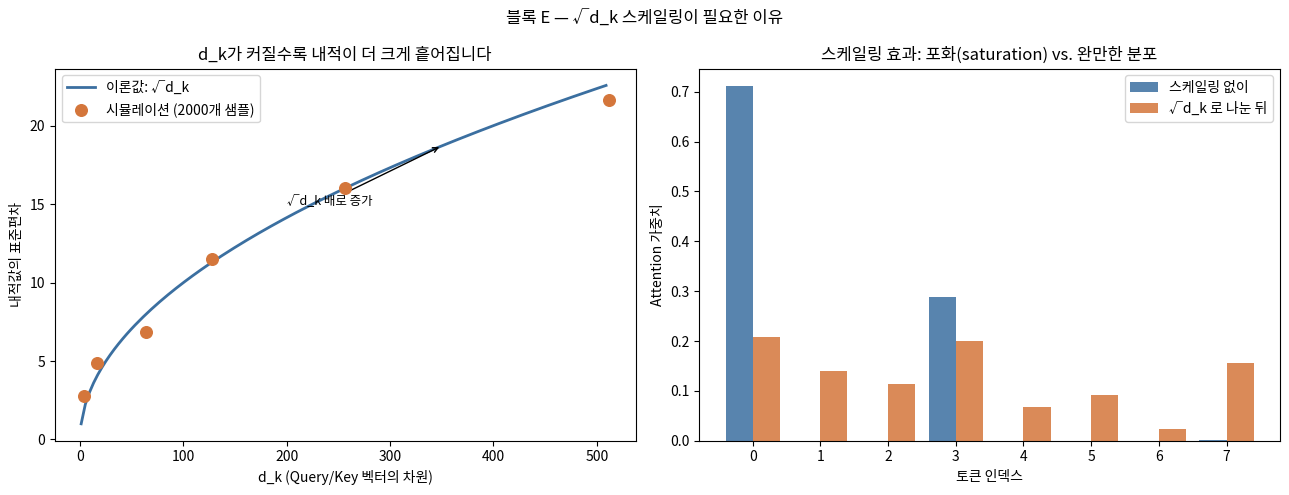

In [5]:
# ============================================================
# 블록 E — √d_k 스케일링 효과 실험
# ============================================================

print("실험: d_k를 다르게 하면서 내적값이 얼마나 흩어지는지 측정합니다.")
print(f"{'d_k':>6} | {'이론값 √d_k':>12} | {'실측 표준편차 (전)':>20} | {'실측 표준편차 (후)':>20}")
print("-" * 67)

n_samples = 2000
torch.manual_seed(0)

for dk in [1, 4, 16, 64, 256, 512]:
    q      = torch.randn(1, dk)
    k      = torch.randn(n_samples, dk)
    dots   = (q * k).sum(dim=-1)           # 내적: shape (n_samples,)
    raw    = dots.std().item()
    scaled = (dots / math.sqrt(dk)).std().item()
    print(f"{dk:>6} | {math.sqrt(dk):>12.3f} | {raw:>20.3f} | {scaled:>20.3f}")

print()
print("=> d_k 가 1→512로 커질수록 스케일링 전 표준편차는 √d_k에 비례해 증가하지만,")
print("   √d_k로 나누면 표준편차가 항상 ≈1.0으로 유지됩니다.")
print()

# ── softmax 포화(saturation) 시연 ─────────────────────────────
print("softmax 포화 비교: d_k=512 일 때 크기를 흉내낸 점수 8개로 실험")
torch.manual_seed(1)
dummy_scores = torch.randn(8) * math.sqrt(512)   # 표준편차 ≈ 22 로 흩어진 점수
sw_raw    = F.softmax(dummy_scores, dim=-1)
sw_scaled = F.softmax(dummy_scores / math.sqrt(512), dim=-1)
print(f"  점수:              {[f'{v:.1f}' for v in dummy_scores.tolist()]}")
print(f"  스케일링 없이:     {[f'{v:.3f}' for v in sw_raw.tolist()]}")
print(f"  √d_k 로 나눈 뒤:  {[f'{v:.3f}' for v in sw_scaled.tolist()]}")
print()
print("  => 스케일링 없이: 거의 한 곳에 확률이 몰립니다 (포화).")
print("     √d_k 후:       확률이 완만하게 퍼집니다.")

# ── 시각화 ──────────────────────────────────────────────────
dk_range   = list(range(1, 513, 4))
theory_std = [math.sqrt(d) for d in dk_range]

torch.manual_seed(0)
emp_dks  = [4, 16, 64, 128, 256, 512]
emp_stds = []
for d in emp_dks:
    q = torch.randn(1, d); k = torch.randn(n_samples, d)
    emp_stds.append((q * k).sum(dim=-1).std().item())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 왼쪽: 이론값 vs 시뮬레이션
ax = axes[0]
ax.plot(dk_range, theory_std, label="이론값: √d_k", color="#3b6fa0", lw=2)
ax.scatter(emp_dks, emp_stds, color="#d4763b", zorder=5, s=70,
           label=f"시뮬레이션 ({n_samples}개 샘플)")
ax.set_xlabel("d_k (Query/Key 벡터의 차원)"); ax.set_ylabel("내적값의 표준편차")
ax.set_title("d_k가 커질수록 내적이 더 크게 흩어집니다")
ax.legend()
ax.annotate("√d_k 배로 증가", xy=(350, math.sqrt(350)),
            xytext=(200, 15), arrowprops=dict(arrowstyle="->"), fontsize=9)

# 오른쪽: softmax 포화 비교 막대
ax = axes[1]
x_idx = range(8)
ax.bar([v - 0.2 for v in x_idx], sw_raw.tolist(), width=0.4,
       label="스케일링 없이", color="#3b6fa0", alpha=0.85)
ax.bar([v + 0.2 for v in x_idx], sw_scaled.tolist(), width=0.4,
       label="√d_k 로 나눈 뒤", color="#d4763b", alpha=0.85)
ax.set_xticks(list(x_idx)); ax.set_xlabel("토큰 인덱스")
ax.set_ylabel("Attention 가중치"); ax.legend(loc="upper right")
ax.set_title("스케일링 효과: 포화(saturation) vs. 완만한 분포")

fig.suptitle("블록 E — √d_k 스케일링이 필요한 이유", fontsize=12)
plt.tight_layout(); plt.show()

## 블록 F — 마스킹(Masking): 미래를 가리는 방법

트랜스포머 **디코더**는 텍스트를 **왼쪽 → 오른쪽** 으로 한 토큰씩 생성합니다.
학습 시에는 모든 토큰을 한꺼번에 처리하기 때문에,
"아직 만들지 않은 **미래 토큰을 참고하면 안 된다**"는 제약이 필요합니다.

이를 **Causal Mask** (인과 마스크 / Look-Ahead Mask) 라고 합니다.

```
        나는  어제  학교에  갔다
나는   [  O    X     X      X  ]   '나는'은 자신만 볼 수 있음
어제   [  O    O     X      X  ]   '어제'는 앞 1개까지
학교에 [  O    O     O      X  ]
갔다   [  O    O     O      O  ]   '갔다'는 전체를 볼 수 있음
```

X 위치를 `-1e9`로 채운 뒤 softmax 를 취하면 해당 위치의 가중치가 ≈ 0 이 됩니다.

> **-1e9 vs float('-inf'):**
> 한 행의 *모든* 위치가 가려지면 `-inf`로 softmax를 취했을 때 결과가 `NaN`이 됩니다.
> 이런 상황은 드물지만, 안전을 위해 많은 구현체가 `-1e9`를 사용합니다.

[causal_mask  (1=볼 수 있음, 0=차단)]
           나는    어제  학교에    갔다
   나는    1.00    0.00    0.00    0.00
   어제    1.00    1.00    0.00    0.00
 학교에    1.00    1.00    1.00    0.00
   갔다    1.00    1.00    1.00    1.00

[masked_scores  (차단 위치 = -1e9)]
           나는    어제  학교에    갔다
   나는   -0.04-1000000000.00-1000000000.00-1000000000.00
   어제   -0.10    0.61-1000000000.00-1000000000.00
 학교에   -0.01    0.42   -0.18-1000000000.00
   갔다   -0.77   -0.06    0.26   -0.31

[attention weights  (차단됐던 위치 = 0.00)]
           나는    어제  학교에    갔다
   나는    1.00    0.00    0.00    0.00
   어제    0.33    0.67    0.00    0.00
 학교에    0.30    0.45    0.25    0.00
   갔다    0.13    0.27    0.38    0.21

검증: 각 행의 합이 1.0 인지 확인합니다.
  '나는' 행의 합: 1.000000
  '어제' 행의 합: 1.000000
  '학교에' 행의 합: 1.000000
  '갔다' 행의 합: 1.000000
=> 미래 토큰으로 가는 가중치가 정확히 0.00 이 됩니다.

──────────────────────────────────────────────────
심화: -1e9 vs float('-inf') — 한 행이 모두 차단된 극단적인 경우
──────────────────────────────────────────────────
  -1e9 → sof

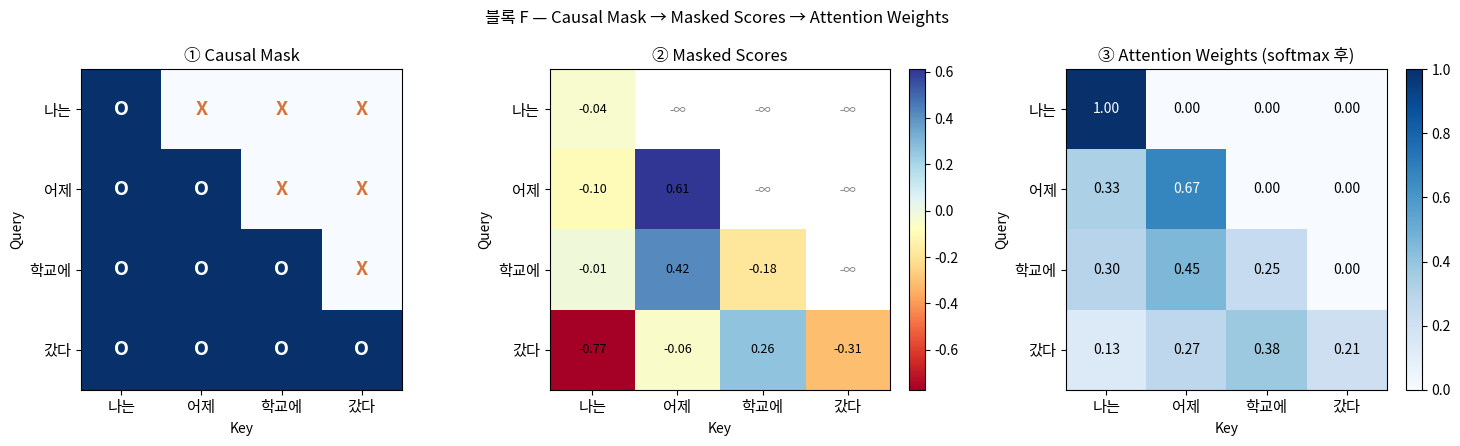

In [6]:
# ============================================================
# 블록 F — Causal Mask 동작 확인
# ============================================================

# ── 마스크 만들기 ───────────────────────────────────────────
# torch.tril: 대각선 아래(포함)는 1, 나머지는 0인 하삼각 행렬
causal_mask = torch.tril(torch.ones(seq_len, seq_len))
show_matrix(causal_mask, tokens, tokens,
            title="causal_mask  (1=볼 수 있음, 0=차단)")

# ── masked_fill 적용 ────────────────────────────────────────
# masked_fill(condition, value):
#   condition이 True인 위치를 value로 덮어씌웁니다.
# causal_mask==0 → 상삼각 위치 → -1e9로 채우기
scores_to_mask = scores_scaled.clone()   # 블록 D에서 만든 스케일된 점수 복사
masked_scores_f = scores_to_mask.masked_fill(causal_mask == 0, -1e9)
show_matrix(masked_scores_f[0], tokens, tokens,
            title="masked_scores  (차단 위치 = -1e9)")

# ── softmax 후 확인 ─────────────────────────────────────────
attn_weights_f = F.softmax(masked_scores_f, dim=-1)
show_matrix(attn_weights_f[0], tokens, tokens,
            title="attention weights  (차단됐던 위치 = 0.00)")

print("검증: 각 행의 합이 1.0 인지 확인합니다.")
for tok, s in zip(tokens, attn_weights_f[0].sum(dim=-1).tolist()):
    print(f"  '{tok}' 행의 합: {s:.6f}")
print("=> 미래 토큰으로 가는 가중치가 정확히 0.00 이 됩니다.")
print()

# ── -1e9 vs float('-inf') 비교 ──────────────────────────────
print("─" * 50)
print("심화: -1e9 vs float('-inf') — 한 행이 모두 차단된 극단적인 경우")
print("─" * 50)
all_big_neg = torch.tensor([[-1e9, -1e9, -1e9]])
all_inf_neg = torch.tensor([[float('-inf'), float('-inf'), float('-inf')]])
print(f"  -1e9 → softmax → {F.softmax(all_big_neg, dim=-1).tolist()}")
print(f"   -∞  → softmax → {F.softmax(all_inf_neg, dim=-1).tolist()}")
print()
print("  -1e9: 모두 균등 분포 (안전, padding mask와 함께 쓸 때 유리)")
print("   -∞ : NaN 발생 (일반 causal mask만 쓸 때는 문제 없지만 주의 필요)")

# ── 시각화 ──────────────────────────────────────────────────
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# (1) Causal Mask
ax = axes[0]
ax.imshow(causal_mask.numpy(), cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(seq_len)); ax.set_xticklabels(tokens, fontsize=11)
ax.set_yticks(range(seq_len)); ax.set_yticklabels(tokens, fontsize=11)
for i in range(seq_len):
    for j in range(seq_len):
        v = int(causal_mask[i, j].item())
        ax.text(j, i, "O" if v else "X", ha="center", va="center",
                color="white" if v else "#d4763b", fontsize=14, fontweight="bold")
ax.set_title("① Causal Mask"); ax.set_xlabel("Key"); ax.set_ylabel("Query")

# (2) Masked Scores
ax = axes[1]
display_mat = masked_scores_f[0].detach().numpy().copy()
display_mat[display_mat < -100] = float('nan')  # -1e9 위치는 NaN (시각화만 목적)
im = ax.imshow(display_mat, cmap="RdYlBu", aspect="auto")
ax.set_xticks(range(seq_len)); ax.set_xticklabels(tokens, fontsize=11)
ax.set_yticks(range(seq_len)); ax.set_yticklabels(tokens, fontsize=11)
for i in range(seq_len):
    for j in range(seq_len):
        raw = masked_scores_f[0, i, j].item()
        label = "-∞" if raw < -100 else f"{raw:.2f}"
        color = "gray" if raw < -100 else "black"
        ax.text(j, i, label, ha="center", va="center", fontsize=9, color=color)
ax.set_title("② Masked Scores"); ax.set_xlabel("Key"); ax.set_ylabel("Query")
fig.colorbar(im, ax=ax, fraction=0.046)

# (3) Attention Weights
ax = axes[2]
w = attn_weights_f[0].detach().numpy()
im = ax.imshow(w, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(seq_len)); ax.set_xticklabels(tokens, fontsize=11)
ax.set_yticks(range(seq_len)); ax.set_yticklabels(tokens, fontsize=11)
for i in range(seq_len):
    for j in range(seq_len):
        v = w[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="white" if v > 0.55 else "black", fontsize=10)
ax.set_title("③ Attention Weights (softmax 후)"); ax.set_xlabel("Key"); ax.set_ylabel("Query")
fig.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle("블록 F — Causal Mask → Masked Scores → Attention Weights", fontsize=12)
plt.tight_layout(); plt.show()

## 블록 G — nn.Module 클래스로 감싸기

지금까지 블록 C–F 에서 한 단계씩 손으로 계산한 내용을
이제 **재사용 가능한 `nn.Module` 클래스**로 정리합니다.

`nn.Module` 을 상속받으면:
- `forward()` 를 정의해 두면 `module(input)` 처럼 함수처럼 호출할 수 있습니다.
- `model.train()` / `model.eval()` 로 Dropout 등의 모드를 한 번에 전환합니다.
- `parameters()` 로 학습 가능한 가중치를 optimizer에 전달할 수 있습니다.

In [7]:
# ============================================================
# ScaledDotProductAttention — nn.Module 버전
# ============================================================

class ScaledDotProductAttention(nn.Module):
    """
    논문 식: Attention(Q, K, V) = softmax(QKᵀ / √d_k) · V

    Parameters
    ----------
    d_k     : Query/Key 벡터의 차원 (스케일 계산에 사용)
    dropout : 학습 시 적용할 드롭아웃 확률 (기본값 0.1 = 10% 무작위 차단)

    Note: dropout은 학습 모드(train())에서만 활성화됩니다.
          추론 모드(eval())에서는 자동으로 비활성화됩니다.
    """
    def __init__(self, d_k: int, dropout: float = 0.1):
        super().__init__()
        self.d_k   = d_k
        self.scale = math.sqrt(d_k)    # √d_k를 미리 계산해 forward 때마다 재계산 방지
        self.dropout = nn.Dropout(dropout)
        # Dropout: 학습 시 attention weight 일부를 무작위로 0으로 만들어
        # 특정 토큰에 과도하게 의존하는 것(overfitting)을 방지합니다.

    def forward(self, Q, K, V, mask=None):
        """
        Parameters
        ----------
        Q, K, V : (batch, [heads,] seq, d_k) — head 차원은 선택적
        mask    : (seq, seq) 또는 (batch, 1, seq, seq) — 브로드캐스팅 자동 적용
        Returns
        -------
        output      : (batch, [heads,] seq, d_k)
        attn_weights: (batch, [heads,] seq, seq)  — 시각화에 활용
        """
        # 1단계: 유사도 점수
        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale

        # 2단계: 마스킹 (선택 사항)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        # 3단계: softmax → 확률 분포로 변환
        attn_weights = F.softmax(scores, dim=-1)

        # 4단계: 드롭아웃 적용 (train 모드일 때만)
        attn_weights = self.dropout(attn_weights)

        # 5단계: Value의 가중 평균 → 최종 출력
        output = torch.matmul(attn_weights, V)

        return output, attn_weights


# ── 검증: 클래스 결과 == 블록 D 수작업 결과인지 확인 ─────────
torch.manual_seed(42)
W_Q = nn.Linear(d_model, d_k)
W_K = nn.Linear(d_model, d_k)
W_V = nn.Linear(d_model, d_k)
torch.manual_seed(42)
X   = torch.randn(1, seq_len, d_model)
Q   = W_Q(X); K = W_K(X); V = W_V(X)
causal_mask = torch.tril(torch.ones(seq_len, seq_len))

sdpa = ScaledDotProductAttention(d_k=d_k, dropout=0.0)
sdpa.eval()
out_class, w_class = sdpa(Q, K, V, mask=causal_mask)

# 수작업 계산과 비교
out_manual = torch.matmul(
    F.softmax(
        (Q @ K.transpose(-2,-1) / math.sqrt(d_k)).masked_fill(causal_mask==0, -1e9),
        dim=-1
    ), V
)
print(f"클래스 결과 == 수작업 결과? {torch.allclose(out_class, out_manual)}")
print(f"출력 shape: {tuple(out_class.shape)}")
print()

# ── dropout 효과 시각화 ──────────────────────────────────────
print("dropout 효과 비교 (p=0.3):")
print("  학습 모드(train): 일부 가중치가 0으로 차단됩니다.")
print("  추론 모드(eval) : dropout 비활성화, 원래 분포를 그대로 유지합니다.")
print()

torch.manual_seed(7)
sdpa_drop = ScaledDotProductAttention(d_k=d_k, dropout=0.3)

sdpa_drop.train()
_, w_train = sdpa_drop(Q, K, V, mask=causal_mask)
show_matrix(w_train[0], tokens, tokens,
            title="학습모드 (dropout=0.3): 일부 weight = 0.00 으로 차단됨")

sdpa_drop.eval()
_, w_eval = sdpa_drop(Q, K, V, mask=causal_mask)
show_matrix(w_eval[0], tokens, tokens,
            title="추론모드 (eval): 원래 attention 분포 유지")

클래스 결과 == 수작업 결과? True
출력 shape: (1, 4, 8)

dropout 효과 비교 (p=0.3):
  학습 모드(train): 일부 가중치가 0으로 차단됩니다.
  추론 모드(eval) : dropout 비활성화, 원래 분포를 그대로 유지합니다.

[학습모드 (dropout=0.3): 일부 weight = 0.00 으로 차단됨]
           나는    어제  학교에    갔다
   나는    1.43    0.00    0.00    0.00
   어제    0.00    0.00    0.00    0.00
 학교에    0.00    0.00    0.36    0.00
   갔다    0.19    0.39    0.54    0.00

[추론모드 (eval): 원래 attention 분포 유지]
           나는    어제  학교에    갔다
   나는    1.00    0.00    0.00    0.00
   어제    0.33    0.67    0.00    0.00
 학교에    0.30    0.45    0.25    0.00
   갔다    0.13    0.27    0.38    0.21



## 블록 H — Multi-Head Attention

Single-Head Attention은 Q/K/V를 **하나의 관점**에서만 처리합니다.
**Multi-Head Attention**은 d_model 차원을 `num_heads`개로 **나눠서**
각 Head가 서로 다른 관점(어순, 의미, 지시대명사 등)을 **동시에** 학습하게 합니다.

```
d_model = 512,  num_heads = 8  →  d_k = 512/8 = 64 (head 하나의 차원)

         ┌── Head 1 (d_k=64): 어순 관계 학습
X ──W─── ├── Head 2 (d_k=64): 동사-목적어 관계
         ├── Head 3~7 ...
         └── Head 8 (d_k=64): 다른 언어적 특성
              ↓  head들을 이어붙임 (concat) → 다시 512차원
              ↓  W_O (선형 변환)
              output (512차원)
```

**Shape 흐름:**

```
X        : (batch, seq, d_model)
W_Q(X)   : (batch, seq, d_model)             ← 아직 head 분할 전
.view()  : (batch, seq, heads, d_k)
.transpose: (batch, heads, seq, d_k)         ← head가 독립적으로 Attention 계산

Attention 후:
attn_out : (batch, heads, seq, d_k)
.transpose: (batch, seq, heads, d_k)
.view()  : (batch, seq, d_model)             ← head 재결합 (concat)
W_O()    : (batch, seq, d_model)             ← 최종 선형 변환
```

In [8]:
# ============================================================
# MultiHeadAttention — 논문 Section 3.2.2 완전 구현
# ============================================================

class MultiHeadAttention(nn.Module):
    """
    논문의 Multi-Head Attention.
    내부적으로 ScaledDotProductAttention을 num_heads 개 동시에 실행합니다.

    Parameters
    ----------
    d_model   : 입출력 차원 (논문 기본값 512)
    num_heads : 병렬 Attention head 수 (논문 기본값 8)
    dropout   : 드롭아웃 확률
    """
    def __init__(self, d_model: int = 512, num_heads: int = 8, dropout: float = 0.1):
        super().__init__()
        assert d_model % num_heads == 0, \
            f"d_model({d_model})은 num_heads({num_heads})의 배수여야 합니다"

        self.d_k       = d_model // num_heads   # head 하나의 차원
        self.num_heads = num_heads
        self.d_model   = d_model

        # ── 4개의 선형 변환 레이어 ─────────────────────────────
        # nn.Linear(d_model, d_model) 하나로 모든 head의 투영을 한 번에 처리합니다.
        # (내부적으로는 각 head가 d_k차원씩 담당)
        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)
        self.W_O = nn.Linear(d_model, d_model)   # head 결합 후 최종 투영

        self.attention = ScaledDotProductAttention(self.d_k, dropout)

    def forward(self, query, key, value, mask=None):
        """
        Parameters
        ----------
        query, key, value : (batch, seq, d_model)
          - 인코더 self-attention : query=key=value=인코더 입력
          - 디코더 self-attention : query=key=value=디코더 입력
          - 크로스 attention      : query=디코더, key=value=인코더 출력
        mask : (seq, seq) 또는 (batch, 1, seq, seq)
        """
        batch_size = query.size(0)

        # ── Step 1: 선형 투영 + head 분할 ─────────────────────
        # W_Q(query): (batch, seq, d_model)
        # .view(batch, -1, heads, d_k): (batch, seq, heads, d_k)
        # .transpose(1, 2):             (batch, heads, seq, d_k)
        # -1 은 'seq_len을 자동으로 계산하라'는 의미입니다
        Q = self.W_Q(query).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_K(key  ).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_V(value).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        # ── Step 2: 모든 head에서 Scaled Dot-Product Attention ─
        # mask: (seq, seq) → (batch, heads, seq, seq) 로 자동 브로드캐스팅
        attn_out, attn_weights = self.attention(Q, K, V, mask)
        # attn_out:     (batch, heads, seq, d_k)
        # attn_weights: (batch, heads, seq, seq)

        # ── Step 3: head 재결합(concat) + 최종 선형 투영 ───────
        # .transpose(1, 2):  (batch, seq, heads, d_k)
        # .contiguous():     메모리를 연속 배치로 재정렬 → .view() 전 필요
        # .view(...):        (batch, seq, d_model)  ← head 이어붙이기
        attn_out = (attn_out
                    .transpose(1, 2)
                    .contiguous()
                    .view(batch_size, -1, self.num_heads * self.d_k))
        output = self.W_O(attn_out)   # (batch, seq, d_model)

        return output, attn_weights

print("ScaledDotProductAttention, MultiHeadAttention 클래스 정의 완료")

ScaledDotProductAttention, MultiHeadAttention 클래스 정의 완료


In [9]:
# ============================================================
# 블록 H — MultiHeadAttention 내부 shape 변화 단계별 추적
# ============================================================

# ── 소규모 설정으로 직접 따라가기 ──────────────────────────────
d_model_s   = 8     # 작은 모델 차원
num_heads_s = 2     # head 수
# → d_k = 8/2 = 4  (head 하나가 4차원씩 담당)

torch.manual_seed(42)
X_s   = torch.randn(1, seq_len, d_model_s)
mha_s = MultiHeadAttention(d_model=d_model_s, num_heads=num_heads_s, dropout=0.0)
mha_s.eval()

print(f"설정: d_model={d_model_s}, num_heads={num_heads_s}, d_k={mha_s.d_k}")
print(f"      {d_model_s} = {num_heads_s}(heads) × {mha_s.d_k}(d_k)")
print(f"입력 X: {tuple(X_s.shape)}")
print()

batch_size = X_s.size(0)
causal_mask = torch.tril(torch.ones(seq_len, seq_len))

# Step 1a: W_Q 통과
Q_proj = mha_s.W_Q(X_s)
print(f"Step 1a | W_Q(X)                       → {tuple(Q_proj.shape)}")
print(f"         아직 head로 분할되기 전 — d_model={d_model_s} 그대로 유지")

# Step 1b: view 로 head별로 나누기
Q_view = Q_proj.view(batch_size, -1, num_heads_s, mha_s.d_k)
print(f"Step 1b | .view(batch, seq, heads, d_k) → {tuple(Q_view.shape)}")

# Step 1c: transpose 로 head를 앞으로 이동
Q_t = Q_view.transpose(1, 2)
print(f"Step 1c | .transpose(1, 2)              → {tuple(Q_t.shape)}")
print(f"          (batch, heads, seq, d_k)  — head가 독립적으로 연산 가능한 형태")
print()

K_t = mha_s.W_K(X_s).view(batch_size, -1, num_heads_s, mha_s.d_k).transpose(1, 2)
V_t = mha_s.W_V(X_s).view(batch_size, -1, num_heads_s, mha_s.d_k).transpose(1, 2)

# Step 2: Attention
attn_out, attn_w = mha_s.attention(Q_t, K_t, V_t, mask=causal_mask)
print(f"Step 2  | Attention(Q, K, V)             → attn_out:    {tuple(attn_out.shape)}")
print(f"                                           → attn_weights:{tuple(attn_w.shape)}")
print()

# Step 3a: transpose 복원
attn_t = attn_out.transpose(1, 2)
print(f"Step 3a | .transpose(1, 2)              → {tuple(attn_t.shape)}")

# Step 3b: view 로 head 이어붙이기 (concat)
concat = attn_t.contiguous().view(batch_size, -1, num_heads_s * mha_s.d_k)
print(f"Step 3b | .view(batch, seq, d_model)    → {tuple(concat.shape)}  (head들이 다시 합쳐짐)")

# Step 3c: W_O
final_out = mha_s.W_O(concat)
print(f"Step 3c | W_O(concat)                   → {tuple(final_out.shape)}")
print()

# 검증
out_direct, _ = mha_s(X_s, X_s, X_s, mask=causal_mask)
print(f"[검증] 단계별 결과 == forward() 직접 호출? {torch.allclose(out_direct, final_out)}")
print(f"       입력 {tuple(X_s.shape)} → 출력 {tuple(out_direct.shape)}  (shape 보존)")

설정: d_model=8, num_heads=2, d_k=4
      8 = 2(heads) × 4(d_k)
입력 X: (1, 4, 8)

Step 1a | W_Q(X)                       → (1, 4, 8)
         아직 head로 분할되기 전 — d_model=8 그대로 유지
Step 1b | .view(batch, seq, heads, d_k) → (1, 4, 2, 4)
Step 1c | .transpose(1, 2)              → (1, 2, 4, 4)
          (batch, heads, seq, d_k)  — head가 독립적으로 연산 가능한 형태

Step 2  | Attention(Q, K, V)             → attn_out:    (1, 2, 4, 4)
                                           → attn_weights:(1, 2, 4, 4)

Step 3a | .transpose(1, 2)              → (1, 4, 2, 4)
Step 3b | .view(batch, seq, d_model)    → (1, 4, 8)  (head들이 다시 합쳐짐)
Step 3c | W_O(concat)                   → (1, 4, 8)

[검증] 단계별 결과 == forward() 직접 호출? True
       입력 (1, 4, 8) → 출력 (1, 4, 8)  (shape 보존)


In [10]:
# ============================================================
# 블록 H — 논문 원래 설정으로 실행 (d_model=512, num_heads=8)
# ============================================================

torch.manual_seed(42)
mha_paper = MultiHeadAttention(d_model=512, num_heads=8, dropout=0.1)
x_paper   = torch.randn(2, 10, 512)     # batch=2, seq=10, d_model=512
out_paper, w_paper = mha_paper(x_paper, x_paper, x_paper)  # self-attention

print("─" * 60)
print("논문 원래 설정")
print("─" * 60)
print(f"  d_model    = 512")
print(f"  num_heads  = 8")
print(f"  d_k        = 512 / 8 = {mha_paper.d_k}  (head 하나의 차원)")
print()
print(f"  입력 shape:       {tuple(x_paper.shape)}")
print(f"  → 출력 shape:     {tuple(out_paper.shape)}  (입력과 동일)")
print(f"  → attn_weights:   {tuple(w_paper.shape)}  (batch, heads=8, seq, seq)")
print()

# ── 파라미터 수 계산 ─────────────────────────────────────────
total = sum(p.numel() for p in mha_paper.parameters())
print("─" * 60)
print("파라미터 수")
print("─" * 60)
for name, layer in [("W_Q", mha_paper.W_Q), ("W_K", mha_paper.W_K),
                    ("W_V", mha_paper.W_V), ("W_O", mha_paper.W_O)]:
    p = sum(x.numel() for x in layer.parameters())
    print(f"  {name}: {p:>10,}  (512×512 가중치 + 512 편향 = {512*512}+{512})")
print(f"  합계: {total:>10,}")
print(f"  = 4 × ({512*512}+{512}) = {4*(512*512+512):,}  ✓")
print()

# ── [실험] num_heads를 다르게 하면? ────────────────────────────
print("─" * 60)
print("[실험] num_heads를 다르게 해도 파라미터 수는 변하지 않습니다")
print("─" * 60)
print(f"  {'num_heads':>10} | {'d_k':>6} | {'총 파라미터':>14}")
print(f"  {'-'*36}")
for nh in [1, 2, 4, 8, 16, 32, 64]:
    m = MultiHeadAttention(d_model=512, num_heads=nh, dropout=0.0)
    p = sum(x.numel() for x in m.parameters())
    print(f"  {nh:>10} | {m.d_k:>6} | {p:>14,}")
print()
print("  => num_heads를 바꿔도 총 파라미터 수는 동일합니다.")
print("     대신 각 head가 더 작은 차원(d_k)에서 작업합니다.")
print("     head가 많을수록 더 다양한 관점으로 정보를 처리합니다.")

────────────────────────────────────────────────────────────
논문 원래 설정
────────────────────────────────────────────────────────────
  d_model    = 512
  num_heads  = 8
  d_k        = 512 / 8 = 64  (head 하나의 차원)

  입력 shape:       (2, 10, 512)
  → 출력 shape:     (2, 10, 512)  (입력과 동일)
  → attn_weights:   (2, 8, 10, 10)  (batch, heads=8, seq, seq)

────────────────────────────────────────────────────────────
파라미터 수
────────────────────────────────────────────────────────────
  W_Q:    262,656  (512×512 가중치 + 512 편향 = 262144+512)
  W_K:    262,656  (512×512 가중치 + 512 편향 = 262144+512)
  W_V:    262,656  (512×512 가중치 + 512 편향 = 262144+512)
  W_O:    262,656  (512×512 가중치 + 512 편향 = 262144+512)
  합계:  1,050,624
  = 4 × (262144+512) = 1,050,624  ✓

────────────────────────────────────────────────────────────
[실험] num_heads를 다르게 해도 파라미터 수는 변하지 않습니다
────────────────────────────────────────────────────────────
   num_heads |    d_k |         총 파라미터
  ------------------------------------
          

## 블록 I — Attention Weight 시각화

각 Head가 문장에서 **어떤 토큰에 얼마나 주목하는지**를 히트맵으로 확인합니다.

> 학습이 완료된 실제 모델에서는 Head마다 뚜렷하게 다른 패턴(문법, 의미, 참조 등)이 나타납니다.
> 지금은 학습 전 임의 가중치이므로 패턴에 의미는 없지만,
> **Causal Mask 삼각형 구조**(우상단=0)는 명확히 확인할 수 있습니다.

설정: d_model=16, num_heads=4, d_k=4
attention weights shape: (1, 4, 4, 4)

각 Head의 Attention Weight (텍스트 형태):
[Head 1]
           나는    어제  학교에    갔다
   나는    1.00    0.00    0.00    0.00
   어제    0.40    0.60    0.00    0.00
 학교에    0.27    0.45    0.28    0.00
   갔다    0.15    0.40    0.23    0.22

[Head 2]
           나는    어제  학교에    갔다
   나는    1.00    0.00    0.00    0.00
   어제    0.31    0.69    0.00    0.00
 학교에    0.30    0.39    0.31    0.00
   갔다    0.22    0.25    0.27    0.26

[Head 3]
           나는    어제  학교에    갔다
   나는    1.00    0.00    0.00    0.00
   어제    0.50    0.50    0.00    0.00
 학교에    0.39    0.29    0.33    0.00
   갔다    0.15    0.13    0.33    0.39

[Head 4]
           나는    어제  학교에    갔다
   나는    1.00    0.00    0.00    0.00
   어제    0.38    0.62    0.00    0.00
 학교에    0.40    0.28    0.32    0.00
   갔다    0.25    0.30    0.26    0.18



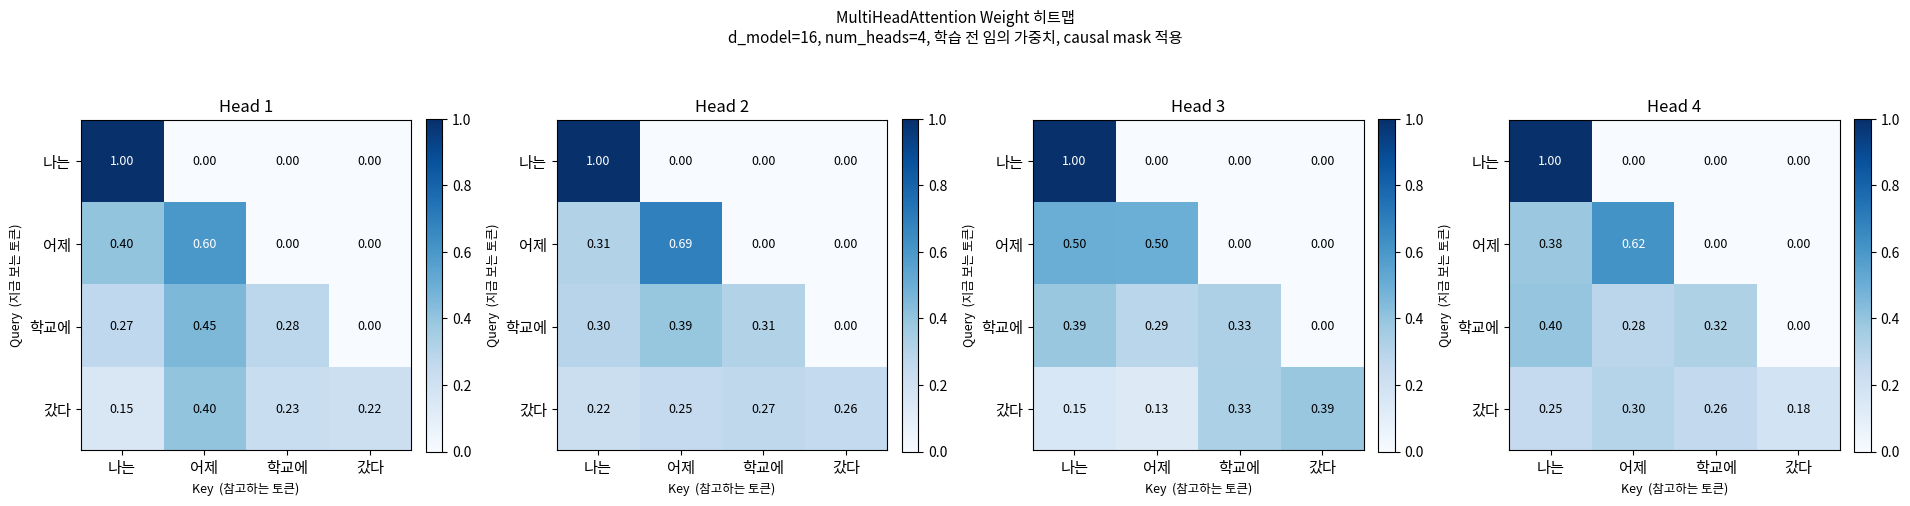


히트맵 읽는 법:
  - 진한 파란색: attention weight가 높음 (많이 참고함)
  - 연한 파란색: attention weight가 낮음 (적게 참고함)
  - 0.00 (우상단): causal mask로 완전히 차단된 미래 토큰
  - 각 행의 합: 1.0 (확률 분포이므로)


In [11]:
# ============================================================
# 블록 I — 각 Head의 Attention Weight 히트맵
# ============================================================

# [실험] d_model_v 와 num_heads_v 를 바꿔보세요
d_model_v   = 16   # [실험]
num_heads_v = 4    # [실험] (d_model_v 의 약수여야 합니다)

torch.manual_seed(42)
X_v   = torch.randn(1, seq_len, d_model_v)
mha_v = MultiHeadAttention(d_model=d_model_v, num_heads=num_heads_v, dropout=0.0)
mha_v.eval()
causal_mask = torch.tril(torch.ones(seq_len, seq_len))
_, attn_w_v = mha_v(X_v, X_v, X_v, mask=causal_mask)
# attn_w_v: (batch=1, num_heads, seq_len, seq_len)

print(f"설정: d_model={d_model_v}, num_heads={num_heads_v}, d_k={mha_v.d_k}")
print(f"attention weights shape: {tuple(attn_w_v.shape)}")
print()

# 텍스트로 먼저 확인
print("각 Head의 Attention Weight (텍스트 형태):")
for h in range(num_heads_v):
    show_matrix(attn_w_v[0, h], tokens, tokens, title=f"Head {h+1}")

# ── 히트맵 시각화 ────────────────────────────────────────────
n_show = min(num_heads_v, 4)   # 최대 4개 head만 한 줄에 표시
fig, axes = plt.subplots(1, n_show, figsize=(4.8 * n_show, 5.2))
if n_show == 1:
    axes = [axes]

for h, ax in enumerate(axes):
    w = attn_w_v[0, h].detach().numpy()
    im = ax.imshow(w, cmap="Blues", vmin=0, vmax=1)

    ax.set_xticks(range(seq_len)); ax.set_xticklabels(tokens, fontsize=11)
    ax.set_yticks(range(seq_len)); ax.set_yticklabels(tokens, fontsize=11)
    ax.set_xlabel("Key  (참고하는 토큰)", fontsize=9)
    ax.set_ylabel("Query  (지금 보는 토큰)", fontsize=9)
    ax.set_title(f"Head {h+1}", fontsize=12)

    for i in range(seq_len):
        for j in range(seq_len):
            v = w[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9,
                    color="white" if v > 0.55 else "black")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

suptitle = (f"MultiHeadAttention Weight 히트맵\n"
            f"d_model={d_model_v}, num_heads={num_heads_v}, 학습 전 임의 가중치, causal mask 적용")
if num_heads_v > 4:
    suptitle += f"\n(처음 4개 head만 표시, 나머지 {num_heads_v-4}개 생략)"

fig.suptitle(suptitle, fontsize=11)
plt.tight_layout(); plt.show()

print()
print("히트맵 읽는 법:")
print("  - 진한 파란색: attention weight가 높음 (많이 참고함)")
print("  - 연한 파란색: attention weight가 낮음 (적게 참고함)")
print("  - 0.00 (우상단): causal mask로 완전히 차단된 미래 토큰")
print("  - 각 행의 합: 1.0 (확률 분포이므로)")

## 부록 A — Label Smoothing (논문 Section 5.4)

일반 Cross-Entropy는 정답 토큰에 확률 1.0, 나머지에 0.0을 목표로 학습합니다.
이렇게 하면 모델이 과자신(overconfident)해져서 일반화 능력이 떨어집니다.

**Label Smoothing (ε = 0.1)** 은 목표 분포를 부드럽게 만듭니다:

```
정답 위치:   1.0  →  confidence = 1.0 − ε = 0.9
비정답 위치: 0.0  →  ε / (vocab_size − 2) ≈ 0.025   (padding 제외)
padding:      0    (학습에서 완전히 제외)
```

이렇게 하면 모델이 "틀릴 수도 있다"는 여지를 학습하게 되어,
Perplexity(혼잡도)는 약간 올라가지만 실제 번역 품질(BLEU)이 향상됩니다.

In [12]:
# ============================================================
# 부록 A — Label Smoothing 동작 확인
# ============================================================

class LabelSmoothing(nn.Module):
    """
    논문 Section 5.4: ε = 0.1 label smoothing.

    Parameters
    ----------
    vocab_size  : 단어장 크기 (정답 분포 벡터의 길이)
    padding_idx : 무시할 인덱스 (보통 0 = <PAD>)
    smoothing   : ε 값 (논문: 0.1)
    """
    def __init__(self, vocab_size: int, padding_idx: int = 0, smoothing: float = 0.1):
        super().__init__()
        # KLDivLoss: 예측 분포와 목표 분포 사이의 KL 발산을 계산합니다.
        # 일반 CrossEntropyLoss 대신 사용하는 이유:
        # → 목표를 one-hot이 아닌 임의의 분포로 자유롭게 설정할 수 있기 때문입니다.
        self.criterion   = nn.KLDivLoss(reduction='sum')
        self.padding_idx = padding_idx
        self.confidence  = 1.0 - smoothing    # 정답 칸에 줄 확률
        self.smoothing   = smoothing
        self.vocab_size  = vocab_size

    def forward(self, pred, target):
        """
        Parameters
        ----------
        pred   : (batch_seq, vocab_size) — log_softmax 적용된 로그 확률
        target : (batch_seq,)            — 정수 인덱스 (정답 토큰 ID)
        """
        # 모든 칸을 ε / (V-2) 로 초기화
        true_dist = torch.zeros_like(pred)
        true_dist.fill_(self.smoothing / (self.vocab_size - 2))

        # 정답 인덱스 칸만 confidence(0.9)로 덮어쓰기
        true_dist.scatter_(1, target.unsqueeze(1), self.confidence)

        # padding 위치 처리: 완전히 0으로
        true_dist[:, self.padding_idx] = 0
        true_dist[target == self.padding_idx] = 0.0

        return self.criterion(pred, true_dist.detach())


# ── 목표 분포 직접 확인 ────────────────────────────────────────
vocab_size = 6   # 0(padding), 1, 2, 3, 4, 5
smoothing  = 0.1

print(f"vocab_size={vocab_size}, padding_idx=0, smoothing={smoothing}")
print(f"  confidence (정답 칸)         = 1 - {smoothing} = {1-smoothing}")
print(f"  비정답 칸 하나의 확률         = {smoothing} / (V-2) = {smoothing/(vocab_size-2):.4f}")
print()

# 예시: target=[1, 4, 0]  → 마지막(0)은 padding
target = torch.tensor([1, 4, 0])

# true_dist 수동 계산 (클래스 내부와 동일)
true_dist = torch.zeros(3, vocab_size)
true_dist.fill_(smoothing / (vocab_size - 2))
true_dist.scatter_(1, target.unsqueeze(1), 1.0 - smoothing)
true_dist[:, 0] = 0
true_dist[target == 0] = 0.0

print("목표 분포 true_dist:")
header = f"  {'':12} " + "  ".join(f"{'칸'+str(i):>8}" for i in range(vocab_size))
print(header)
for i, row in enumerate(true_dist):
    tgt = target[i].item()
    label = f"[정답={tgt}, PAD]" if tgt == 0 else f"[정답={tgt}]"
    vals  = "  ".join(f"{v:>8.4f}" for v in row.tolist())
    print(f"  {label:<14} {vals}")
print()
print("  (3번째 행은 padding → 전부 0 → 손실 계산에서 제외됨)")
print()

# ── 실제 손실 비교 ────────────────────────────────────────────
logits = torch.randn(3, vocab_size)
pred   = F.log_softmax(logits, dim=-1)   # KLDivLoss는 log-확률이 입력

ls         = LabelSmoothing(vocab_size=vocab_size, padding_idx=0, smoothing=smoothing)
loss_ls    = ls(pred, target)
loss_plain = F.nll_loss(pred, target, ignore_index=0, reduction='sum')

print(f"Label Smoothing 손실: {loss_ls.item():.4f}")
print(f"일반 NLL 손실 (비교): {loss_plain.item():.4f}")
print()
print("=> Label Smoothing 손실이 일반 NLL 손실보다 낮게 나오는 이유:")
print("   '비정답 토큰들'에도 소량의 확률(0.025씩)을 목표로 설정해서")
print("   KL 발산의 총합이 줄기 때문입니다.")
print("   실제 효과는 학습 과정의 과자신 방지 → BLEU 점수 향상입니다.")

vocab_size=6, padding_idx=0, smoothing=0.1
  confidence (정답 칸)         = 1 - 0.1 = 0.9
  비정답 칸 하나의 확률         = 0.1 / (V-2) = 0.0250

목표 분포 true_dist:
                     칸0        칸1        칸2        칸3        칸4        칸5
  [정답=1]           0.0000    0.9000    0.0250    0.0250    0.0250    0.0250
  [정답=4]           0.0000    0.0250    0.0250    0.0250    0.9000    0.0250
  [정답=0, PAD]      0.0000    0.0000    0.0000    0.0000    0.0000    0.0000

  (3번째 행은 padding → 전부 0 → 손실 계산에서 제외됨)

Label Smoothing 손실: 4.6306
일반 NLL 손실 (비교): 5.5718

=> Label Smoothing 손실이 일반 NLL 손실보다 낮게 나오는 이유:
   '비정답 토큰들'에도 소량의 확률(0.025씩)을 목표로 설정해서
   KL 발산의 총합이 줄기 때문입니다.
   실제 효과는 학습 과정의 과자신 방지 → BLEU 점수 향상입니다.


## 부록 B — 학습률 스케줄 (논문 Section 5.3)

논문은 Adam optimizer와 함께 아래 학습률 스케줄을 사용합니다:

$$\text{lr} = d_{\text{model}}^{-0.5} \cdot \min\!\left(\text{step}^{-0.5},\; \text{step} \cdot \text{warmup\_steps}^{-1.5}\right)$$

- **Warmup 구간** (step ≤ warmup_steps): 학습률이 step에 비례해 **선형 증가**
- **Decay 구간** (step > warmup_steps): 학습률이 step의 **역제곱근으로 감소**

논문 기본값: `d_model=512, warmup_steps=4000`
최고점에서의 lr ≈ 7 × 10⁻⁴ (step = warmup_steps 일 때)

> **왜 warmup이 필요한가?**
> 학습 초기에는 가중치가 무작위이므로 gradient가 불안정합니다.
> 이 시기에 큰 학습률을 사용하면 발산할 위험이 있어, 서서히 높여가는 방식을 씁니다.

d_model=512, warmup_steps=4000
이론 최고 lr = 512^(-0.5) × 4000^(-0.5)
            = 0.0006988   (step=4000 일 때)



    step |          학습률 | 단계
----------------------------------------
       1 |    0.0000002 | warmup ↑
     500 |    0.0000873 | warmup ↑
    1000 |    0.0001747 | warmup ↑
    4000 |    0.0006988 | warmup ↑
    8000 |    0.0004941 | decay  ↓
   12000 |    0.0004034 | decay  ↓
   20000 |    0.0003125 | decay  ↓


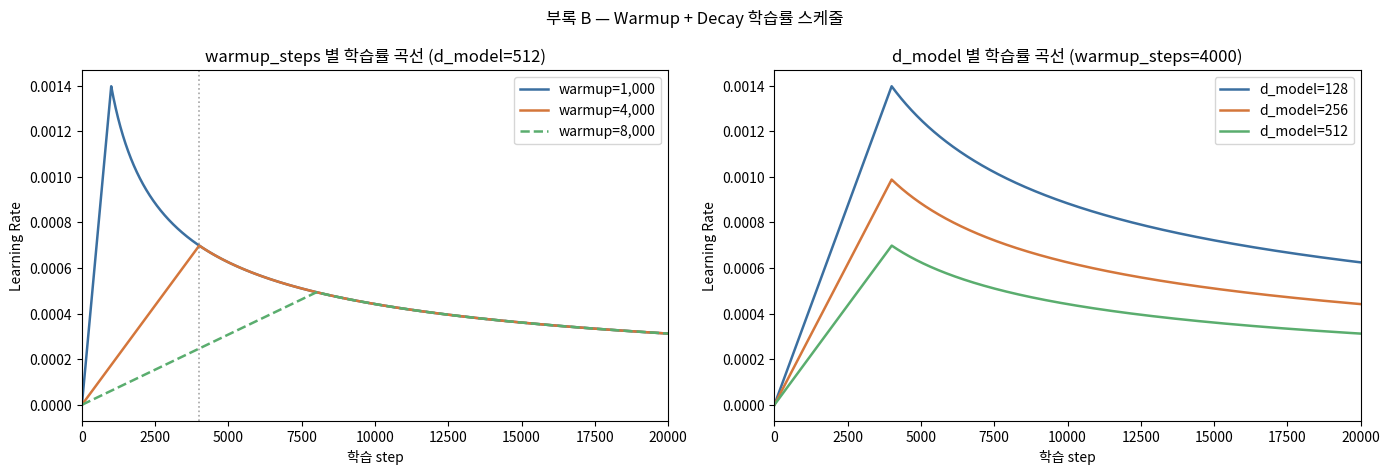


=> warmup_steps가 클수록 더 오래 천천히 올라갔다가 낮은 피크에 도달합니다.
   d_model이 클수록 최고 학습률이 낮습니다 (d_model^(-0.5) 때문).
   큰 모델일수록 학습을 더 조심스럽게 해야 하기 때문입니다.


In [13]:
# ============================================================
# 부록 B — Warmup + Decay 학습률 스케줄
# ============================================================

class TransformerLRScheduler:
    """
    논문 Section 5.3의 Warmup + Inverse-Square-Root Decay 스케줄러.
    (원리 이해를 위한 직접 구현 버전)

    Parameters
    ----------
    optimizer     : PyTorch optimizer 객체
    d_model       : 모델 차원 (기본 512)
    warmup_steps  : warmup 구간 step 수 (기본 4000)
    """
    def __init__(self, optimizer, d_model: int = 512, warmup_steps: int = 4000):
        self.optimizer    = optimizer
        self.d_model      = d_model
        self.warmup_steps = warmup_steps
        self.steps        = 0

    def step(self) -> float:
        """한 step 진행, 현재 학습률을 반환합니다."""
        self.steps += 1
        lr = self.d_model ** (-0.5) * min(
            self.steps ** (-0.5),                         # Decay 항: step이 커질수록 감소
            self.steps * self.warmup_steps ** (-1.5)      # Warmup 항: step에 비례해 증가
        )
        for pg in self.optimizer.param_groups:
            pg['lr'] = lr
        return lr


# ── 이론값 확인 ────────────────────────────────────────────────
d_model_lr   = 512
warmup_steps = 4000
peak_lr_theory = d_model_lr**(-0.5) * warmup_steps**(-0.5)

print(f"d_model={d_model_lr}, warmup_steps={warmup_steps}")
print(f"이론 최고 lr = {d_model_lr}^(-0.5) × {warmup_steps}^(-0.5)")
print(f"            = {peak_lr_theory:.7f}   (step={warmup_steps} 일 때)")
print()

# 시뮬레이션
dummy_model = nn.Linear(4, 4)
optimizer   = torch.optim.Adam(dummy_model.parameters())
scheduler   = TransformerLRScheduler(optimizer, d_model=d_model_lr, warmup_steps=warmup_steps)
n_steps     = 20_000
all_lrs     = [scheduler.step() for _ in range(n_steps)]

print(f"{'step':>8} | {'학습률':>12} | {'단계'}")
print("-" * 40)
for s in [1, 500, 1000, 4000, 8000, 12000, 20000]:
    lr    = all_lrs[s - 1]
    phase = "warmup ↑" if s <= warmup_steps else "decay  ↓"
    print(f"{s:>8} | {lr:>12.7f} | {phase}")

# ── 시각화 ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

# 왼쪽: warmup_steps 비교
ax = axes[0]
for warmup, color, style in [
    (1000,  "#3b6fa0", "-"),
    (4000,  "#d4763b", "-"),
    (8000,  "#5aad6e", "--"),
]:
    m2  = nn.Linear(4, 4)
    o2  = torch.optim.Adam(m2.parameters())
    s2  = TransformerLRScheduler(o2, d_model=512, warmup_steps=warmup)
    l2  = [s2.step() for _ in range(n_steps)]
    ax.plot(range(1, n_steps+1), l2, label=f"warmup={warmup:,}", color=color, lw=1.8, ls=style)

ax.axvline(x=4000, color="gray", linestyle=":", lw=1.2, alpha=0.7)
ax.set_xlabel("학습 step"); ax.set_ylabel("Learning Rate")
ax.set_title("warmup_steps 별 학습률 곡선 (d_model=512)")
ax.legend(); ax.set_xlim(0, n_steps)

# 오른쪽: d_model 비교
ax = axes[1]
for dm, color in [(128, "#3b6fa0"), (256, "#d4763b"), (512, "#5aad6e")]:
    m3 = nn.Linear(4, 4)
    o3 = torch.optim.Adam(m3.parameters())
    s3 = TransformerLRScheduler(o3, d_model=dm, warmup_steps=4000)
    l3 = [s3.step() for _ in range(n_steps)]
    ax.plot(range(1, n_steps+1), l3, label=f"d_model={dm}", color=color, lw=1.8)

ax.set_xlabel("학습 step"); ax.set_ylabel("Learning Rate")
ax.set_title("d_model 별 학습률 곡선 (warmup_steps=4000)")
ax.legend(); ax.set_xlim(0, n_steps)

fig.suptitle("부록 B — Warmup + Decay 학습률 스케줄", fontsize=12)
plt.tight_layout(); plt.show()

print()
print("=> warmup_steps가 클수록 더 오래 천천히 올라갔다가 낮은 피크에 도달합니다.")
print("   d_model이 클수록 최고 학습률이 낮습니다 (d_model^(-0.5) 때문).")
print("   큰 모델일수록 학습을 더 조심스럽게 해야 하기 때문입니다.")

## 실험 셀 — 하이퍼파라미터를 바꿔보고 결과 비교하기

아래 셀의 `[실험]` 표시 값을 바꿔 실행해보세요.

| 변수 | 바꿔볼 범위 | 예상 변화 |
|------|------------|----------|
| `d_model_exp` | 8 / 32 / 128 / 512 | 파라미터 수가 d_model²에 비례해 늘어납니다 |
| `num_heads_exp` | 1 / 2 / 4 / 8 | d_k = d_model/num_heads 가 변합니다 |
| `dropout_exp` | 0.0 / 0.1 / 0.5 | 학습 모드에서 weight가 더 많이 0이 됩니다 |
| `batch_exp` | 1 / 4 / 16 | shape의 첫 번째 차원만 변합니다 |
| `seq_exp` | 4 / 16 / 64 | attention matrix가 seq²에 비례해 커집니다 |

───────────────────────────────────────────────────────
현재 설정 & 결과
───────────────────────────────────────────────────────
  d_model=32, num_heads=4, d_k=8
  dropout=0.1, batch=2, seq_len=6

  입력 X:        (2, 6, 32)
  출력 output:   (2, 6, 32)
  attn_weights:  (2, 4, 6, 6)  (batch, heads, seq, seq)

  파라미터 수: 4,224
  ≈ 4 × 32² = 4,096  (+편향 128)

  Attention Matrix 크기: 6 × 6 = 36 칸
  (seq_len 2배 → Attention Matrix 4배 — O(n²) 복잡도)



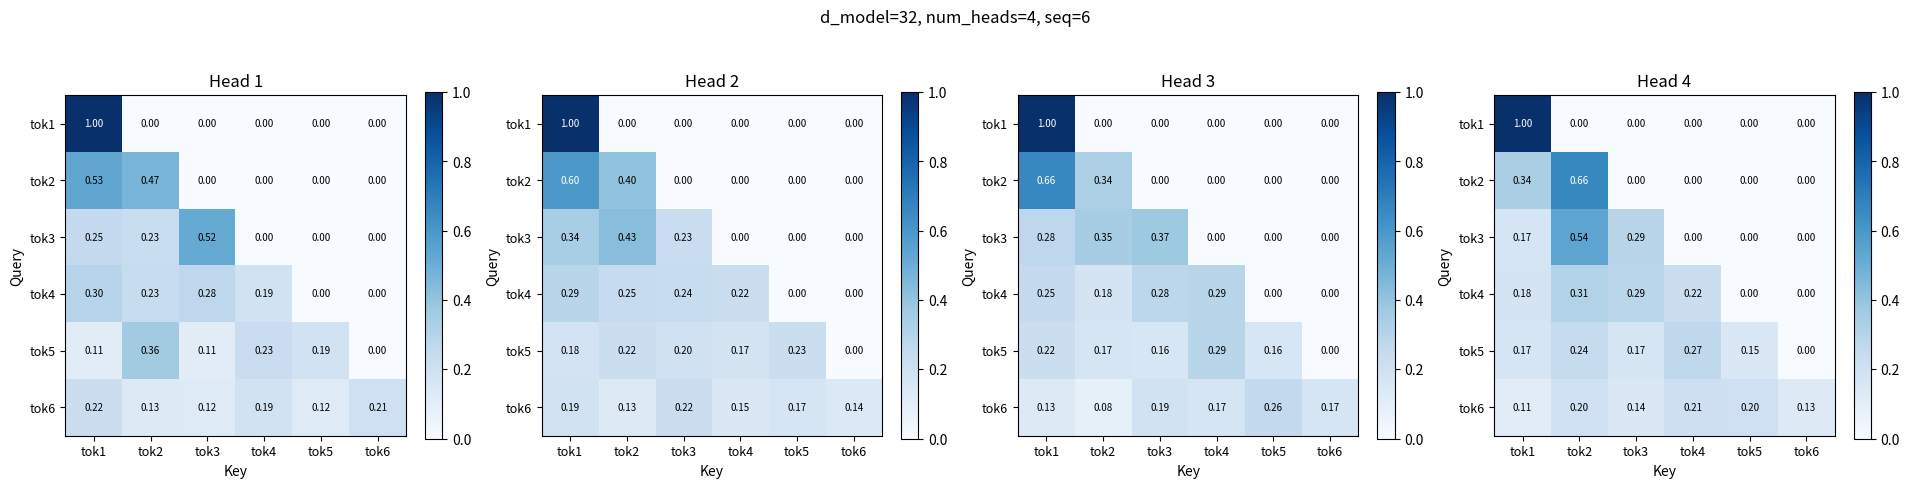

In [14]:
# ============================================================
# 종합 실험 셀 — 하이퍼파라미터를 바꿔 결과 차이 확인
# ============================================================

# ── [실험] 이 값들을 바꿔보세요 ──────────────────────────────
d_model_exp    = 32    # 모델 차원 (num_heads_exp 의 배수여야 합니다)
num_heads_exp  = 4     # Attention head 수
dropout_exp    = 0.1   # 드롭아웃 확률 (0.0 ~ 1.0)
batch_exp      = 2     # 배치 크기
seq_exp        = 6     # 문장 길이(토큰 수)
# ─────────────────────────────────────────────────────────────

assert d_model_exp % num_heads_exp == 0, \
    f"d_model({d_model_exp})이 num_heads({num_heads_exp})의 배수가 아닙니다!"

torch.manual_seed(42)
X_exp   = torch.randn(batch_exp, seq_exp, d_model_exp)
mha_exp = MultiHeadAttention(d_model=d_model_exp, num_heads=num_heads_exp, dropout=dropout_exp)
mha_exp.eval()
mask_exp = torch.tril(torch.ones(seq_exp, seq_exp))
out_exp, w_exp = mha_exp(X_exp, X_exp, X_exp, mask=mask_exp)

total_p = sum(p.numel() for p in mha_exp.parameters())

print("─" * 55)
print("현재 설정 & 결과")
print("─" * 55)
print(f"  d_model={d_model_exp}, num_heads={num_heads_exp}, d_k={d_model_exp//num_heads_exp}")
print(f"  dropout={dropout_exp}, batch={batch_exp}, seq_len={seq_exp}")
print()
print(f"  입력 X:        {tuple(X_exp.shape)}")
print(f"  출력 output:   {tuple(out_exp.shape)}")
print(f"  attn_weights:  {tuple(w_exp.shape)}  (batch, heads, seq, seq)")
print()
print(f"  파라미터 수: {total_p:,}")
print(f"  ≈ 4 × {d_model_exp}² = {4*d_model_exp**2:,}  (+편향 {4*d_model_exp})")
print()
print(f"  Attention Matrix 크기: {seq_exp} × {seq_exp} = {seq_exp**2} 칸")
print(f"  (seq_len 2배 → Attention Matrix 4배 — O(n²) 복잡도)")
print()

# ── 처음 min(heads, 4) 개 head 시각화 ──────────────────────────
n_show      = min(num_heads_exp, 4)
tok_labels  = [f"tok{i+1}" for i in range(seq_exp)]

fig, axes = plt.subplots(1, n_show, figsize=(4.8 * n_show, 5))
if n_show == 1:
    axes = [axes]

for h, ax in enumerate(axes):
    w = w_exp[0, h].detach().numpy()
    im = ax.imshow(w, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(seq_exp)); ax.set_xticklabels(tok_labels, fontsize=9)
    ax.set_yticks(range(seq_exp)); ax.set_yticklabels(tok_labels, fontsize=9)
    ax.set_title(f"Head {h+1}")
    ax.set_xlabel("Key"); ax.set_ylabel("Query")
    for i in range(seq_exp):
        for j in range(seq_exp):
            v = w[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    fontsize=7, color="white" if v > 0.55 else "black")
    fig.colorbar(im, ax=ax, fraction=0.046)

suffix = f"\n(처음 {n_show}개 head 표시)" if num_heads_exp > 4 else ""
fig.suptitle(f"d_model={d_model_exp}, num_heads={num_heads_exp}, seq={seq_exp}{suffix}")
plt.tight_layout(); plt.show()

## 정리 — 이 노트북에서 배운 것

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

| 단계 | 코드 | 핵심 포인트 |
|------|------|-------------|
| Q/K/V 만들기 | `W_Q(X)`, `W_K(X)`, `W_V(X)` | 동일한 X를 세 방향으로 투영 |
| 유사도 점수 | `Q @ Kᵀ` | 내적 = 방향 유사도 |
| 스케일링 | `÷ √d_k` | 분산을 1로 유지, softmax 포화 방지 |
| 마스킹 | `masked_fill(mask==0, -1e9)` | 미래 토큰 차단 |
| 확률화 | `softmax(dim=-1)` | 각 행의 합 = 1 |
| 가중 평균 | `attn_weights @ V` | 문맥을 반영해 정보 혼합 |
| Multi-Head | `view+transpose` → 분리 → `concat+W_O` | 여러 관점 동시 학습 |

### 다음으로 공부할 것
- **Positional Encoding**: 토큰 순서를 어떻게 모델에 알려주는가?
- **Feed-Forward Network**: Attention 다음에 오는 2층 MLP
- **Encoder–Decoder 구조**: Self-Attention vs. Cross-Attention
- **학습 전략**: Padding Mask, Gradient Clipping, 배치 처리